# Transfer Learning ResNet-18 — Dataset Robot Basket (`dataset_raw.zip`)

Notebook ini memakai **dataset dari zip yang kamu punya** (ball, rim, backboard, latar).
**Jalankan sel dari atas ke bawah** (klik ▶ di kiri tiap sel, tunggu selesai, baru lanjut).

| Tahap | Isi |
|---|---|
| 0 | Nyalakan GPU |
| 1 | Pengaturan: pilih kelas |
| 2 | Upload `dataset_raw.zip` |
| 3 | Cek dataset + buang foto yang salah label |
| 4 | Susun data untuk training |
| 5 | Latih ResNet-18 (transfer learning) |
| 6 | Uji → **akurasi** |
| 7 | Buat README + zip untuk GitHub |

## Tahap 0 — Nyalakan GPU (sekali saja)
Menu **Runtime → Change runtime type → T4 GPU → Save**. Supaya training jauh lebih cepat.

In [1]:
import os, random, json, shutil, zipfile, glob
import numpy as np, matplotlib.pyplot as plt
import torch
print("GPU aktif:", torch.cuda.is_available())

GPU aktif: True


## Tahap 1 — Pengaturan: pilih kelas
Tugasmu butuh **minimal 2 kelas**. Zip-mu punya 4 kelas: `ball`, `rim`, `backboard`, `latar`.

- **Disarankan untuk pertama kali:** `["ball", "rim"]` (bola vs ring), karena paling mudah dibedakan.
- Kalau mau lebih menantang, ganti jadi `["ball", "rim", "backboard", "latar"]`.

In [2]:
KELAS = ["ball", "rim"]     # <-- boleh diganti, lihat penjelasan di atas
SUMBER_DATA = "dataset_raw.zip (metadata.csv, kamera e-con See3CAM_CU135, sesi BRAIL-24Sep)"

PROJECT  = "microduck-transfer-learning"
RAW_DIR  = f"{PROJECT}/data/dataset_raw"
PROC_DIR = f"{PROJECT}/data/processed"
for d in ["data", "models", "results"]:
    os.makedirs(f"{PROJECT}/{d}", exist_ok=True)
print("Kelas yang dipakai:", KELAS)

Kelas yang dipakai: ['ball', 'rim']


## Tahap 2 — Upload `dataset_raw.zip`
Jalankan sel ini, klik **Choose files**, lalu pilih `dataset_raw.zip` dari laptopmu.

In [5]:
from google.colab import files
import zipfile
import os

up = files.upload()
for nama in up:
    if not nama.endswith('.zip'):
        print(f"\n[PERINGATAN] File '{nama}' bukan file .zip! Harap upload file 'dataset_raw.zip'.")
        continue

    try:
        with zipfile.ZipFile(nama) as z:
            z.extractall(f"{PROJECT}/data")
        print(f"\nBerhasil mengekstrak {nama}!")
        print("Isi folder dataset:", os.listdir(RAW_DIR))
    except zipfile.BadZipFile:
        print(f"\n[ERROR] File '{nama}' rusak atau bukan format ZIP yang valid.")

Saving dataset_raw.zip to dataset_raw.zip

Berhasil mengekstrak dataset_raw.zip!
Isi folder dataset: ['backboard', 'rim', 'metadata.csv', 'latar', 'ball']


## Tahap 3 — Cek dataset
Sel ini membaca `metadata.csv`, menghitung foto, dan menampilkan contoh tiap kelas.
Kolom `split` di file itu sudah membagi foto jadi train / valid / test, jadi **kita pakai pembagian itu** (tidak diacak ulang).

Semua kelas di zip: {'latar': 173, 'rim': 164, 'ball': 156, 'backboard': 154}

split  test  train  valid
kelas                    
ball     26    115     15
rim      25    118     21


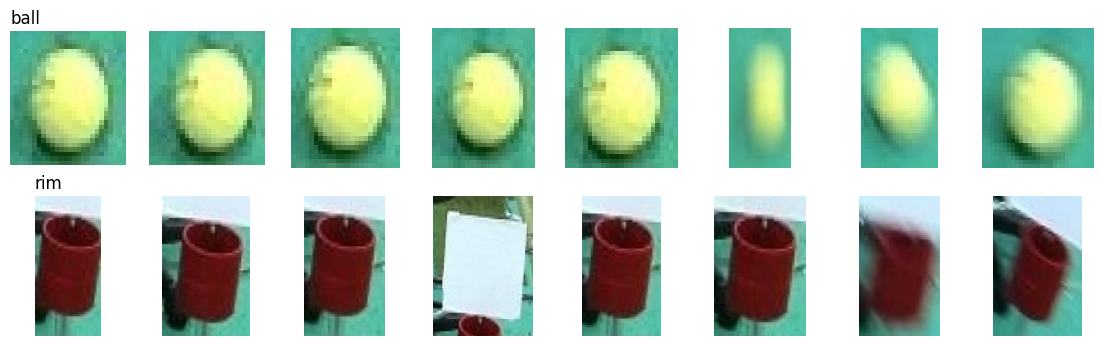

In [6]:
import pandas as pd
from PIL import Image
df = pd.read_csv(f"{RAW_DIR}/metadata.csv")
print("Semua kelas di zip:", df.kelas.value_counts().to_dict())
df = df[df.kelas.isin(KELAS)].copy()
print()
print(pd.crosstab(df.kelas, df.split))

fig, ax = plt.subplots(len(KELAS), 8, figsize=(14, 2*len(KELAS)), squeeze=False)
for i, k in enumerate(KELAS):
    fl = df[df.kelas == k].nama_file.tolist()[:8]
    for j in range(8):
        ax[i][j].axis("off")
        if j < len(fl):
            ax[i][j].imshow(Image.open(f"{RAW_DIR}/{fl[j]}").convert("RGB"))
            if j == 0: ax[i][j].set_title(k, loc="left")
plt.show()

### Tahap 3B — Buang foto yang salah label
Waktu aku memeriksa zip-mu, ada foto yang **salah folder**:
- `rim_20260924_netral_020.jpg` dan `rim_20260924_netral_021.jpg` isinya **bola kuning**, bukan ring
- `rim_20260924_netral_004.jpg` isinya **papan putih (backboard)**, bukan ring

Foto salah label membuat model bingung dan akurasi tampak lebih jelek dari seharusnya. Sel di bawah membuangnya dari training
(file aslinya tidak dihapus). Aku hanya memeriksa sebagian, jadi **lihat galeri di bawahnya** dan tambahkan nama file lain yang menurutmu salah ke daftar `HAPUS`.

In [7]:
HAPUS = [
    "rim/rim_20260924_netral_004.jpg",
    "rim/rim_20260924_netral_020.jpg",
    "rim/rim_20260924_netral_021.jpg",
    # tambahkan nama file lain di sini, contoh: "ball/ball_20260924_netral_050.jpg",
]
df = df[~df.nama_file.isin(HAPUS)].copy()
jumlah = df.kelas.value_counts().to_dict()
print("Dibuang:", len(HAPUS), "foto | Jumlah foto per kelas sekarang:", jumlah)
for k, n in jumlah.items():
    print(("OK    " if n >= 50 else "KURANG"), k, n, "foto (minimal 50)")

Dibuang: 3 foto | Jumlah foto per kelas sekarang: {'rim': 161, 'ball': 156}
OK     rim 161 foto (minimal 50)
OK     ball 156 foto (minimal 50)


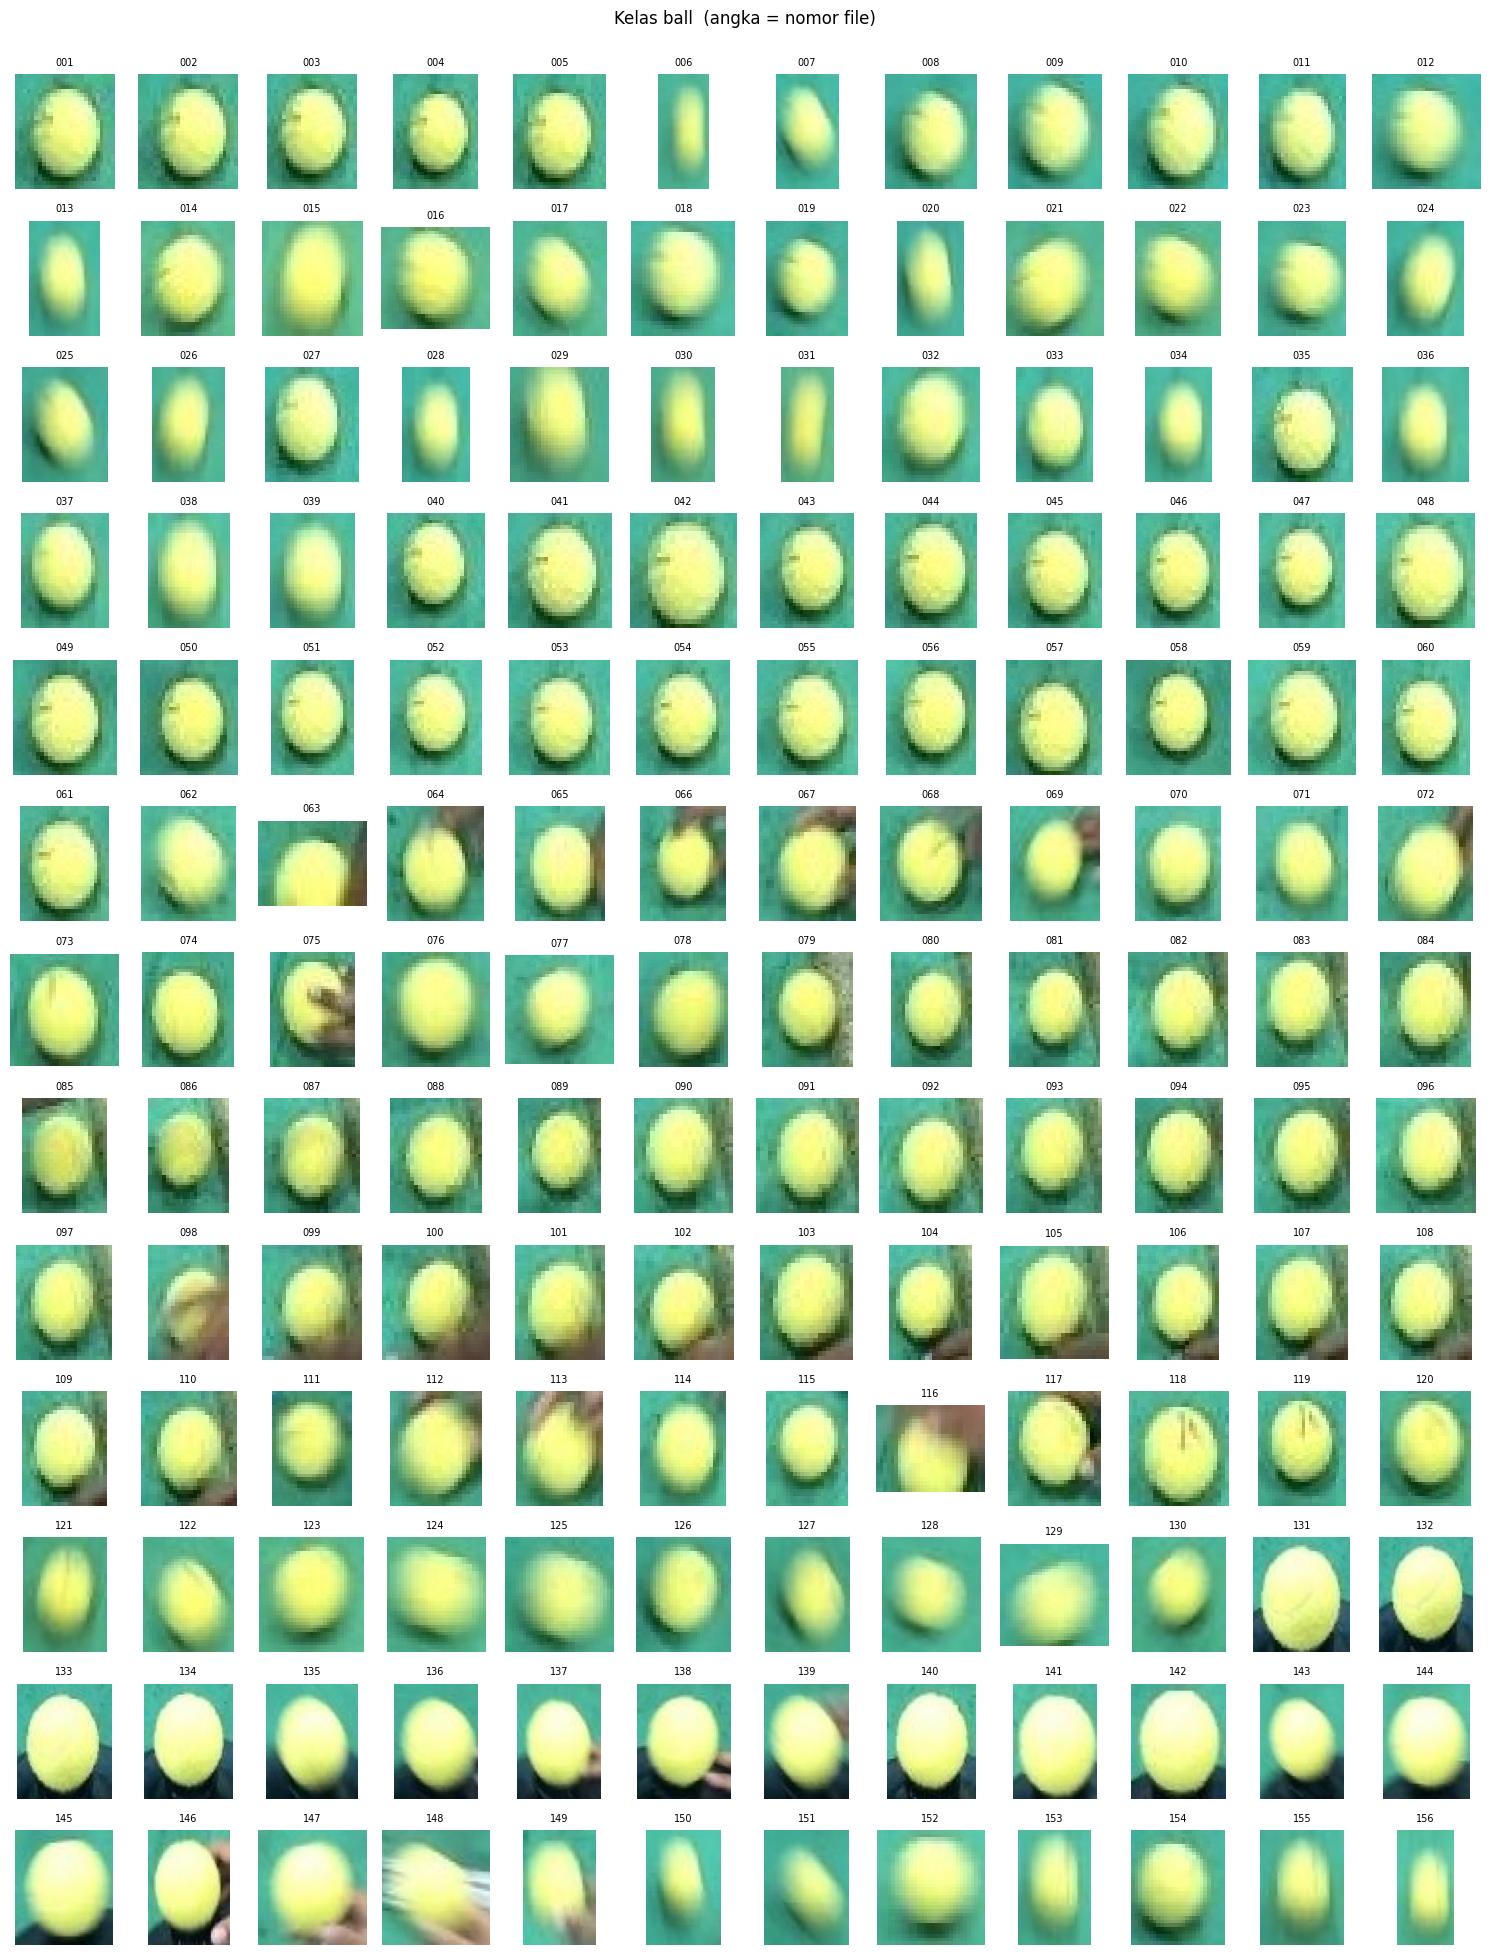

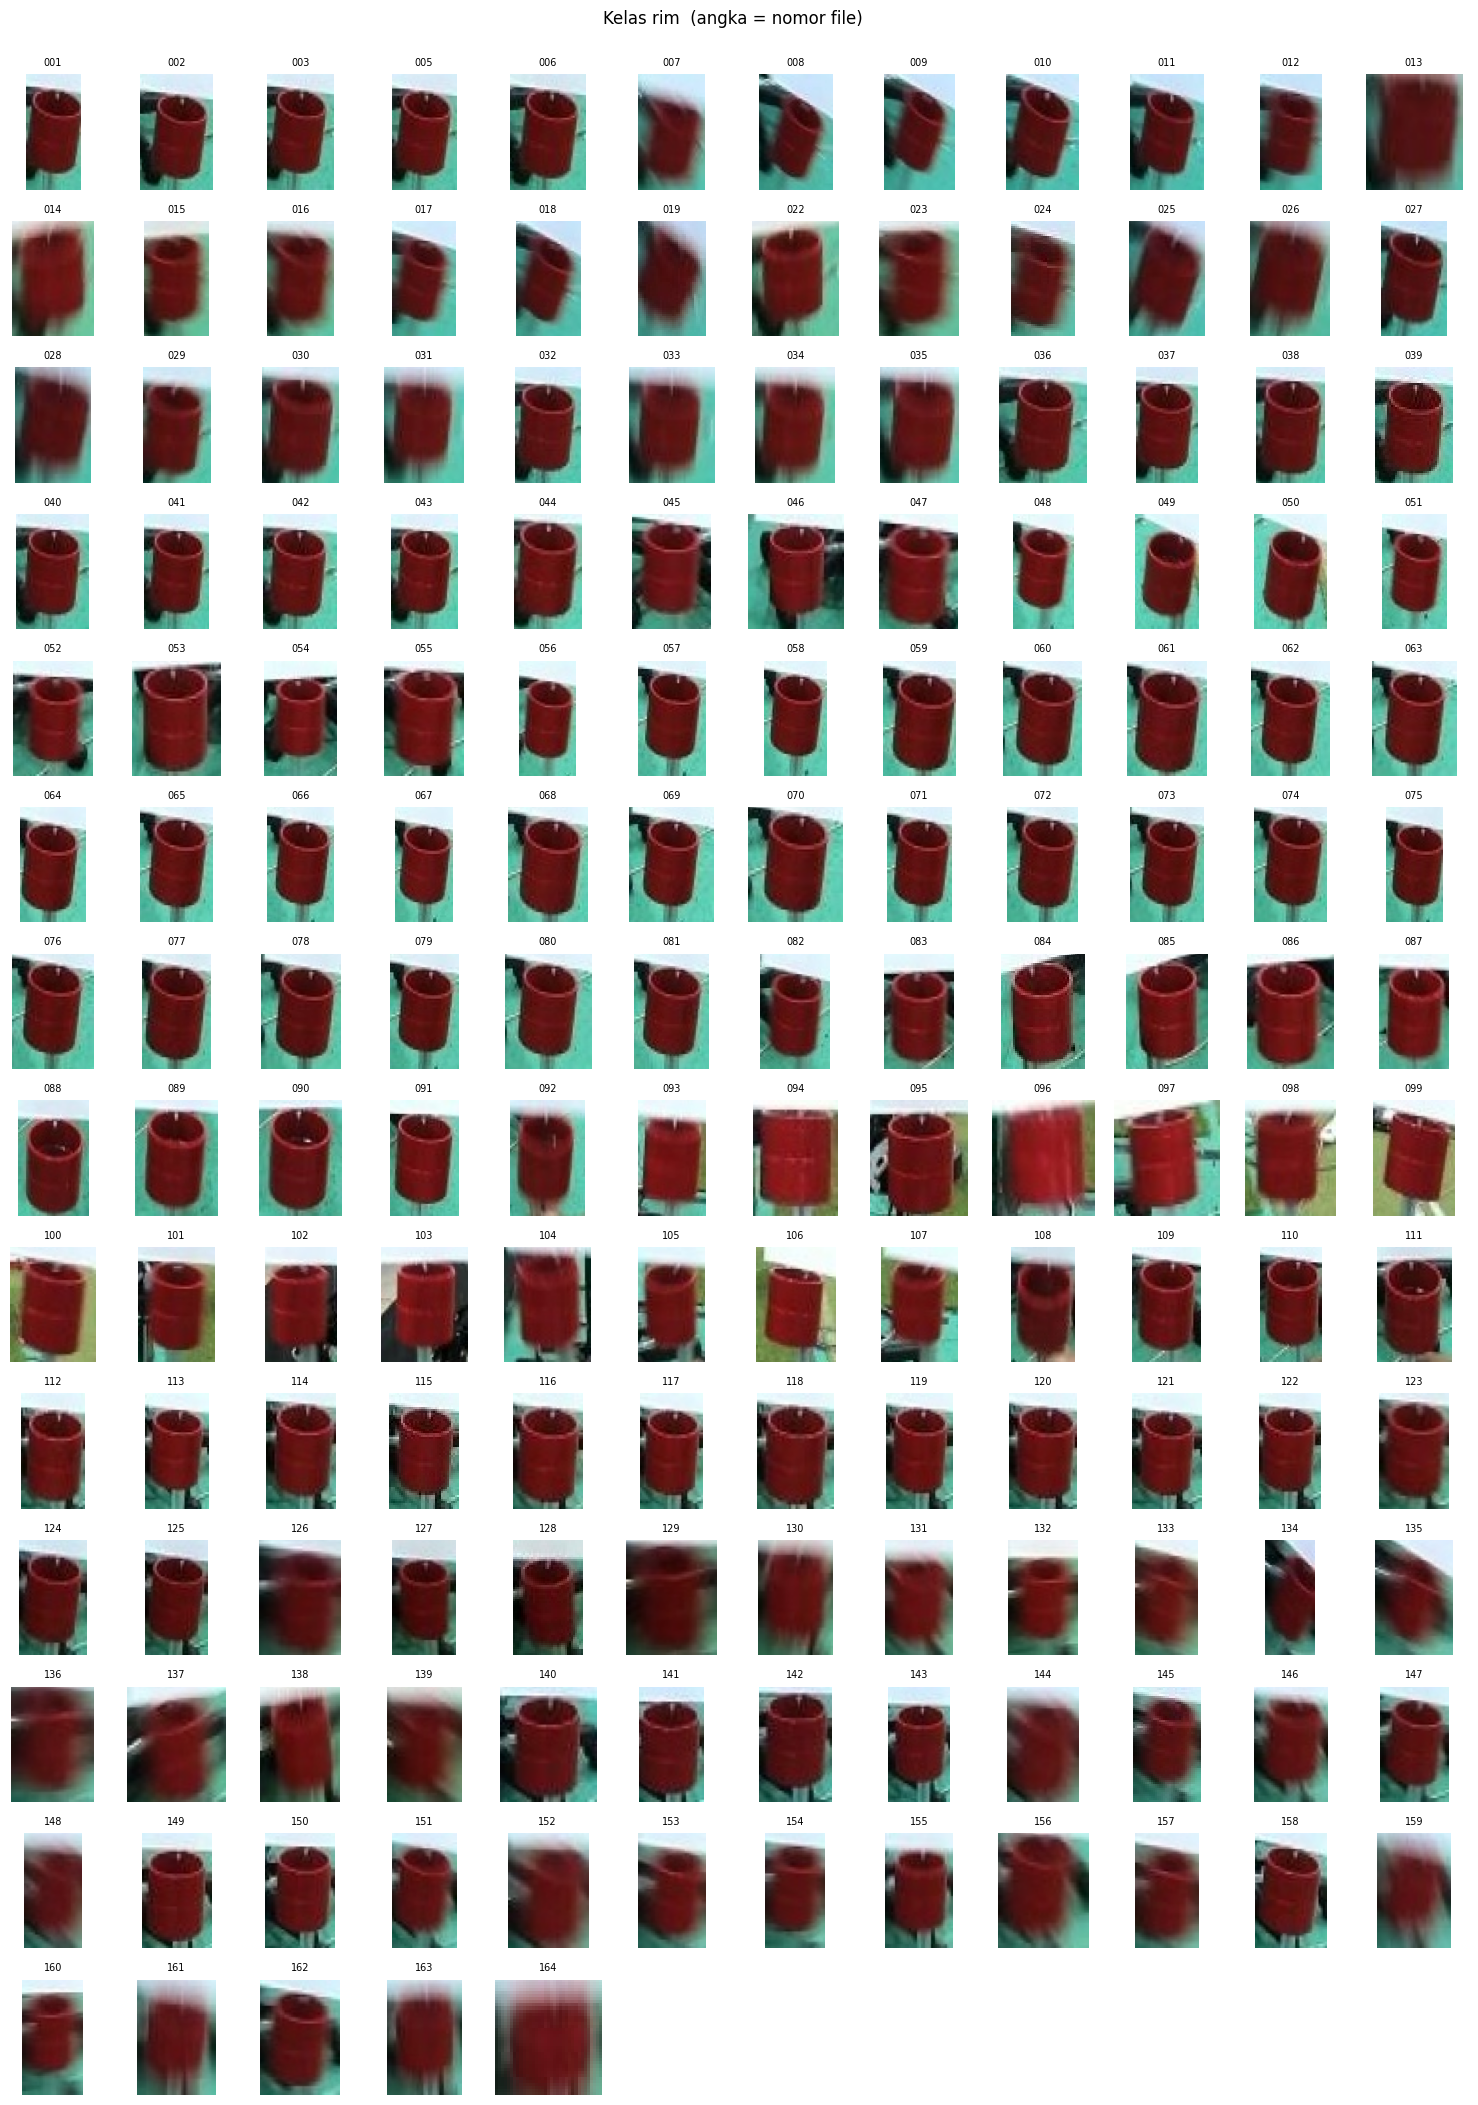

In [8]:
# Galeri semua foto kelas terpilih, lengkap dengan nomor file, untuk memeriksa label salah.
for k in KELAS:
    d = df[df.kelas == k].nama_file.tolist()
    kolom = 12; baris = (len(d) + kolom - 1) // kolom
    fig, ax = plt.subplots(baris, kolom, figsize=(15, 1.5*baris), squeeze=False)
    for a in ax.ravel(): a.axis("off")
    for i, f in enumerate(d):
        ax[i//kolom][i%kolom].imshow(Image.open(f"{RAW_DIR}/{f}").convert("RGB"))
        ax[i//kolom][i%kolom].set_title(f.split("_")[-1].replace(".jpg", ""), fontsize=7)
    fig.suptitle(f"Kelas {k}  (angka = nomor file)", y=1.0)
    plt.tight_layout(); plt.show()

## Tahap 4 — Susun data untuk training
Foto disalin ke folder `train/`, `valid/`, `test/` sesuai kolom `split`.

In [9]:
if os.path.exists(PROC_DIR): shutil.rmtree(PROC_DIR)
for _, r in df.iterrows():
    dst = f"{PROC_DIR}/{r.split}/{r.kelas}"
    os.makedirs(dst, exist_ok=True)
    shutil.copy(f"{RAW_DIR}/{r.nama_file}", dst)
print(pd.crosstab(df.kelas, df.split))

split  test  train  valid
kelas                    
ball     26    115     15
rim      25    115     21


## Tahap 5 — Latih model (transfer learning)
ResNet-18 yang sudah pintar melihat gambar kita "ajari" 2 bendamu dalam 2 tahap:
1. **Tahap A:** hanya layer terakhir yang belajar (cepat, aman).
2. **Tahap B:** satu blok layer lagi ikut disesuaikan dengan pelan-pelan (*fine-tuning*).

Model terbaik disimpan otomatis. Sel ini butuh beberapa menit.

In [10]:
import torch.nn as nn
from torchvision import datasets, models, transforms as T
from torch.utils.data import DataLoader

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
norm = T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
tf_train = T.Compose([T.Resize((224, 224)), T.RandomHorizontalFlip(), T.RandomRotation(10),
                      T.ColorJitter(0.3, 0.3, 0.3), T.ToTensor(), norm])
tf_eval  = T.Compose([T.Resize((224, 224)), T.ToTensor(), norm])

ds = {s: datasets.ImageFolder(f"{PROC_DIR}/{s}", tf_train if s == "train" else tf_eval)
      for s in ["train", "valid", "test"]}
dl = {s: DataLoader(ds[s], batch_size=16, shuffle=(s == "train"), num_workers=2) for s in ds}
NAMA_KELAS = ds["train"].classes
print("Kelas:", NAMA_KELAS, "| Perangkat:", device)

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, len(NAMA_KELAS))
model = model.to(device)
loss_fn = nn.CrossEntropyLoss()
hist = {"train_loss": [], "valid_loss": [], "train_acc": [], "valid_acc": []}
best = {"acc": -1, "loss": 9e9}
MODEL_PATH = f"{PROJECT}/models/resnet18_best.pth"

def bn_eval(m):
    for l in m.modules():
        if isinstance(l, nn.BatchNorm2d): l.eval()

def jalankan(split, train, opt=None):
    model.train() if train else model.eval()
    if train: bn_eval(model)
    tot_loss = ok = n = 0
    with torch.set_grad_enabled(train):
        for x, y in dl[split]:
            x, y = x.to(device), y.to(device)
            out = model(x); loss = loss_fn(out, y)
            if train:
                opt.zero_grad(); loss.backward(); opt.step()
            tot_loss += loss.item() * len(y); ok += (out.argmax(1) == y).sum().item(); n += len(y)
    return tot_loss / n, ok / n

def latih(params, lr, epochs, nama):
    opt = torch.optim.Adam(params, lr=lr)
    for ep in range(epochs):
        tl, ta = jalankan("train", True, opt)
        vl, va = jalankan("valid", False)
        for key, v in zip(hist, [tl, vl, ta, va]): hist[key].append(v)
        print(f"{nama} epoch {ep+1:2d}/{epochs} | train acc {ta:.2%} | valid acc {va:.2%} | valid loss {vl:.3f}")
        if va > best["acc"] or (va == best["acc"] and vl < best["loss"]):
            best.update(acc=va, loss=vl); torch.save(model.state_dict(), MODEL_PATH)

# Tahap A: bekukan semua, latih layer terakhir saja
for p in model.parameters(): p.requires_grad = False
for p in model.fc.parameters(): p.requires_grad = True
latih(model.fc.parameters(), 1e-3, 10, "A")

# Tahap B: buka layer4 + fc, latih pelan-pelan
for p in model.layer4.parameters(): p.requires_grad = True
latih([p for p in model.parameters() if p.requires_grad], 1e-4, 10, "B")
print("\nAkurasi valid terbaik:", f"{best['acc']:.2%}")

Kelas: ['ball', 'rim'] | Perangkat: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 124MB/s]


A epoch  1/10 | train acc 88.70% | valid acc 80.56% | valid loss 0.333
A epoch  2/10 | train acc 98.70% | valid acc 97.22% | valid loss 0.105
A epoch  3/10 | train acc 99.57% | valid acc 100.00% | valid loss 0.079
A epoch  4/10 | train acc 100.00% | valid acc 100.00% | valid loss 0.048
A epoch  5/10 | train acc 100.00% | valid acc 100.00% | valid loss 0.047
A epoch  6/10 | train acc 100.00% | valid acc 100.00% | valid loss 0.033
A epoch  7/10 | train acc 100.00% | valid acc 100.00% | valid loss 0.030
A epoch  8/10 | train acc 99.57% | valid acc 100.00% | valid loss 0.034
A epoch  9/10 | train acc 99.13% | valid acc 100.00% | valid loss 0.033
A epoch 10/10 | train acc 100.00% | valid acc 100.00% | valid loss 0.019
B epoch  1/10 | train acc 100.00% | valid acc 100.00% | valid loss 0.000
B epoch  2/10 | train acc 100.00% | valid acc 100.00% | valid loss 0.000
B epoch  3/10 | train acc 100.00% | valid acc 100.00% | valid loss 0.000
B epoch  4/10 | train acc 100.00% | valid acc 100.00% | va

### Grafik proses belajar

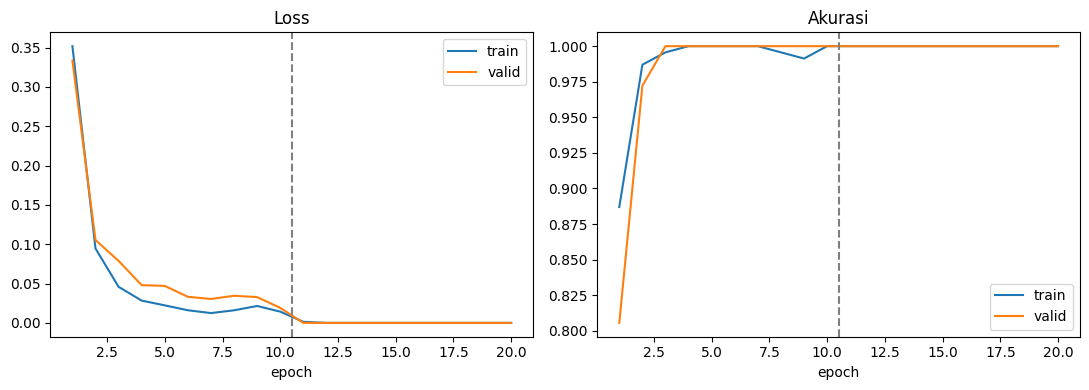

In [11]:
ep = range(1, len(hist["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ep, hist["train_loss"], label="train"); ax[0].plot(ep, hist["valid_loss"], label="valid")
ax[0].axvline(10.5, ls="--", c="gray"); ax[0].set_title("Loss"); ax[0].legend(); ax[0].set_xlabel("epoch")
ax[1].plot(ep, hist["train_acc"], label="train"); ax[1].plot(ep, hist["valid_acc"], label="valid")
ax[1].axvline(10.5, ls="--", c="gray"); ax[1].set_title("Akurasi"); ax[1].legend(); ax[1].set_xlabel("epoch")
plt.tight_layout(); plt.savefig(f"{PROJECT}/results/training_curves.png", dpi=150); plt.show()

## Tahap 6 — Ujian akhir (data test)
Ini **hasil utama tugasmu**: seberapa akurat model membedakan 2 bendamu pada foto yang belum pernah dilihat.

AKURASI TEST: 100.00%  (51 benar dari 51 foto)

              precision    recall  f1-score   support

        ball      1.000     1.000     1.000        26
         rim      1.000     1.000     1.000        25

    accuracy                          1.000        51
   macro avg      1.000     1.000     1.000        51
weighted avg      1.000     1.000     1.000        51



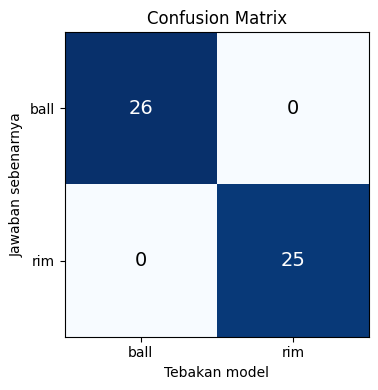

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
model.load_state_dict(torch.load(MODEL_PATH, map_location=device)); model.eval()
y_true, y_pred, salah = [], [], []
with torch.no_grad():
    for i, (x, y) in enumerate(dl["test"]):
        p = model(x.to(device)).argmax(1).cpu()
        y_true += y.tolist(); y_pred += p.tolist()
paths = [s[0] for s in ds["test"].samples]
salah = [(paths[i], NAMA_KELAS[y_true[i]], NAMA_KELAS[y_pred[i]]) for i in range(len(y_true)) if y_true[i] != y_pred[i]]

acc_test = float(np.mean(np.array(y_true) == np.array(y_pred)))
laporan = classification_report(y_true, y_pred, target_names=NAMA_KELAS, digits=3)
print(f"AKURASI TEST: {acc_test:.2%}  ({len(y_true)-len(salah)} benar dari {len(y_true)} foto)\n")
print(laporan)

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(NAMA_KELAS))); ax.set_xticklabels(NAMA_KELAS)
ax.set_yticks(range(len(NAMA_KELAS))); ax.set_yticklabels(NAMA_KELAS)
ax.set_xlabel("Tebakan model"); ax.set_ylabel("Jawaban sebenarnya"); ax.set_title("Confusion Matrix")
for i in range(len(cm)):
    for j in range(len(cm)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)
plt.tight_layout(); plt.savefig(f"{PROJECT}/results/confusion_matrix.png", dpi=150); plt.show()

open(f"{PROJECT}/results/classification_report.txt", "w").write(laporan)
json.dump({"kelas": NAMA_KELAS, "akurasi_test": acc_test, "akurasi_valid_terbaik": best["acc"],
           "jumlah_test": len(y_true), "jumlah_per_kelas": jumlah}, open(f"{PROJECT}/results/metrics.json", "w"), indent=2)

if salah:
    print("Foto yang salah ditebak:")
    fig, ax = plt.subplots(1, min(len(salah), 6), figsize=(14, 3), squeeze=False)
    for a, (pth, asli, tebak) in zip(ax[0], salah[:6]):
        a.imshow(Image.open(pth).convert("RGB")); a.axis("off"); a.set_title(f"asli: {asli}\ntebak: {tebak}", fontsize=9)
    plt.show()

## Tahap 6B — (Opsional) Coba tebak 1 foto baru
Upload satu foto benda, model akan menebak. Cocok untuk demo ke dosen.

In [ ]:
from google.colab import files
def tebak(path):
    img = tf_eval(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad(): pr = torch.softmax(model(img), 1)[0].cpu()
    plt.imshow(Image.open(path)); plt.axis("off")
    plt.title(f"{NAMA_KELAS[pr.argmax()]}  ({pr.max():.1%})"); plt.show()
for nama in files.upload(): tebak(nama)

## Tahap 7 — Buat README + zip untuk GitHub
Sel ini membuat `README.md`, `requirements.txt`, `.gitignore`, lalu membungkus semuanya jadi `hasil_proyek.zip`
dan mengunduhnya ke laptopmu.

In [ ]:
from datetime import date
sesi = ", ".join(map(str, df.sesi.unique())); kam = ", ".join(map(str, df.kamera.unique()))
tgl = ", ".join(map(str, df.tanggal.unique()))
baris = [
 "# Klasifikasi Objek Robot Basket dengan Transfer Learning ResNet-18", "",
 "## Tujuan",
 "Membangun model klasifikasi gambar dengan metode **transfer learning** (ResNet-18 pretrained ImageNet) "
 "untuk membedakan objek yang dilihat robot MicroDuck.", "",
 "## Dataset",
 f"- Sumber: {SUMBER_DATA}  *(isi/ubah keterangan sumber sesuai kenyataan)*",
 f"- Kamera pengambilan data: {kam}; sesi: {sesi}; tanggal: {tgl}",
 f"- Kelas dipakai: {', '.join(NAMA_KELAS)}",
 "- Jumlah foto per kelas (setelah pembersihan): " + ", ".join(f"{k}={v}" for k, v in jumlah.items()),
 f"- Foto salah label yang dibuang: {len(HAPUS)} ({', '.join(HAPUS)})",
 "- Pembagian train/valid/test mengikuti kolom `split` di `metadata.csv` (per frame sumber, tanpa kebocoran antar-split)",
 "- Foto berupa crop objek berukuran kecil (rata-rata sekitar 46x64 px), di-resize ke 224x224", "",
 "## Metode",
 "- Model: ResNet-18 pretrained; layer terakhir diganti sesuai jumlah kelas",
 "- Tahap A: hanya layer `fc` dilatih (10 epoch, lr 1e-3)",
 "- Tahap B: `layer4` + `fc` di-fine-tune (10 epoch, lr 1e-4)",
 "- Augmentasi: flip horizontal, rotasi 10 derajat, color jitter; optimizer Adam; loss CrossEntropy",
 "- Model terbaik dipilih dari akurasi validasi", "",
 "## Hasil",
 f"- **Akurasi test: {acc_test:.2%}** ({len(y_true)-len(salah)} benar dari {len(y_true)} foto)",
 f"- Akurasi validasi terbaik: {best['acc']:.2%}", "",
 "![Kurva training](results/training_curves.png)", "",
 "![Confusion matrix](results/confusion_matrix.png)", "",
 "Laporan lengkap: `results/classification_report.txt`", "",
 "## Keterbatasan",
 "- Data berasal dari satu sesi dan satu kamera dengan kondisi cahaya yang sama; akurasi dengan kamera lain (mis. Logitech) bisa lebih rendah.",
 "- Jumlah data valid/test kecil, sehingga akurasi bisa berubah cukup besar antar-percobaan.",
 "- Frame yang berdekatan mirip satu sama lain, sehingga akurasi bisa terlihat lebih tinggi dari kondisi nyata.",
 "- Model hanya mengklasifikasi crop objek (bukan mendeteksi posisi objek pada frame penuh).", "",
 "## Cara menjalankan ulang",
 "Buka `notebook.ipynb` di Google Colab, aktifkan GPU, upload `dataset_raw.zip`, lalu jalankan semua sel dari atas ke bawah.",
]
open(f"{PROJECT}/README.md", "w").write("\n".join(baris) + "\n")
open(f"{PROJECT}/requirements.txt", "w").write("torch\ntorchvision\nscikit-learn\nmatplotlib\npandas\npillow\n")
open(f"{PROJECT}/.gitignore", "w").write("__pycache__/\n*.pyc\n.venv/\ndata/processed/\n.DS_Store\n")

with zipfile.ZipFile("hasil_proyek.zip", "w", zipfile.ZIP_DEFLATED) as z:
    for root, _, fs in os.walk(PROJECT):
        if "processed" in root.split(os.sep): continue
        for f in fs:
            full = os.path.join(root, f); z.write(full, os.path.relpath(full, "."))
print("Zip dibuat:", round(os.path.getsize("hasil_proyek.zip")/1e6, 1), "MB")
files.download("hasil_proyek.zip")

## Terakhir
1. Menu **File → Download → Download .ipynb**, ganti namanya jadi `notebook.ipynb`, masukkan ke folder proyek hasil ekstrak zip.
2. Upload ke GitHub, lalu kumpulkan link repositorinya.